In [147]:
%pip install umap-learn

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [148]:
# IMPORTS

import pandas as pd
import numpy as np
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve
from sklearn.manifold import TSNE, trustworthiness
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings("ignore")

# for consistent uncertainty transformation
from uncertainty_transformer import UncertaintyTransformer

In [149]:
# CONSTANTS

EXCEL_PATH = "Miyokardit_08.12.xlsx"
LABEL_COL  = "GRUP"
from uncertainty_utils import EPS
from uncertainty_utils import N_BINS

In [150]:
# HELPER CLASS
from uncertainty_utils import (
    discretise,
    get_distribution,
    shannon_entropy,
    js_divergence,
)

In [151]:
FEATURES = [
    'AGE', 'SEX', 'DM', 'HT', 'HL', 'FH', 'SIGARA', 'KBY', 'PRIOR_KAH', 'KOAH',
    'Chest Pain', 'Chest Pain Character', 'Any Previous Pain Attacks',
    'Chest Pain Duration(saat)', 'Radiation', 'Arm Pain', 'Back Pain',
    'Epigastric Pain', 'Relation with exercise', 'Relation with Position',
    'Dyspnea', 'Fatigue', 'Nausea', 'Çarpıntı', 'Recent Infection(4 hafta)',
    'TROP_KATSAYISI', 'CK-MB', 'GLUKOZ', 'WBCpik', 'NEUpik', 'LYMPpik',
    'EOSpik', 'MONOpik', 'HB', 'HTC', 'PLT', 'KREATIN', 'AST', 'ALT',
    'TOTAL_KOLESTEROL', 'TG', 'LDL', 'HDL', 'hs-CRP_KATSAYISI'
]

df_raw = pd.read_excel(EXCEL_PATH)
df_raw = df_raw.replace([" ", "", "-", "--", "nan", "NaN", "None",
                         "#VALUE!", "#N/A", "#REF!", "#DIV/0!", "#NUM!", "#NAME?", "#NULL!"], pd.NA)
df_raw = df_raw.apply(lambda col: col.replace(r'^\s*$', pd.NA, regex=True))
for col in FEATURES:
    if col in df_raw.columns:
        df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")
df = df_raw[FEATURES + [LABEL_COL]].copy()

print("Feature selection shape:", df.shape)

Feature selection shape: (184, 45)


In [152]:
# train/test split

X_raw = df.drop(columns=[LABEL_COL]).copy()
y = df[LABEL_COL].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", len(X_train_raw))
print("Test size :", len(X_test_raw))

# save split indices to disk for reuse in finetuning notebook
split_indices = {
    'train_idx': X_train_raw.index.tolist(),
    'test_idx': X_test_raw.index.tolist(),
    'random_state': 42,
    'test_size': 0.2
}
with open('split_indices.pkl', 'wb') as f:
    pickle.dump(split_indices, f)

print("Split indices saved to: split_indices.pkl")


Train size: 147
Test size : 37
Split indices saved to: split_indices.pkl


In [153]:
# ============================================================================
# PREPROCESSING
# ============================================================================

print("="*80)
print("PREPROCESSING: ELIMINATE NaN VALUES")
print("="*80)

# reconstruct df_train and df_test from split indices
df_train = df.loc[X_train_raw.index].copy()
df_test = df.loc[X_test_raw.index].copy()

print("\n[STEP 1: ELIMINATE ROWS WITH NaN VALUES]")

# training set
initial_train = len(df_train)
df_train = df_train.dropna(axis=0)
final_train = len(df_train)
dropped_train = initial_train - final_train

print(f"  Training set:")
print(f"    Initial: {initial_train} samples")
print(f"    Dropped: {dropped_train} rows with NaN values")
print(f"    Final: {final_train} samples")

# test set
initial_test = len(df_test)
df_test = df_test.dropna(axis=0)
final_test = len(df_test)
dropped_test = initial_test - final_test

print(f"\n  Test set:")
print(f"    Initial: {initial_test} samples")
print(f"    Dropped: {dropped_test} rows with NaN values")
print(f"    Final: {final_test} samples")

print("\n[STEP 2: VERIFICATION]")

train_nans = df_train.isna().sum().sum()
test_nans = df_test.isna().sum().sum()

if train_nans == 0 and test_nans == 0:
    print(f"   SUCCESS: Zero NaN values in both sets")
    print(f"     Training: {len(df_train)} complete samples")
    print(f"     Test: {len(df_test)} complete samples")
else:
    raise ValueError("NaN values still present after elimination - check preprocessing")

# use the same explicit feature list as finetuning.ipynb
features = FEATURES

# create final datasets
X_train_raw = df_train[features].copy()
y_train = df_train[LABEL_COL].values
X_test_raw = df_test[features].copy()
y_test = df_test[LABEL_COL].values

df_clean = pd.concat([df_train, df_test], axis=0)  # for visualization

# calculate class distribution
final_class_counts = df_clean[LABEL_COL].value_counts().sort_index()

print(f"\n{'='*80}")
print("SUMMARY")
print("="*80)
print(f"\nFinal clean data:")
print(f"  Training: {len(df_train)} samples × {len(features)} features")
print(f"  Test: {len(df_test)} samples × {len(features)} features")
print(f"  Total: {len(df_clean)} complete clinical records")

print(f"\nClass distribution:")
for label, count in final_class_counts.items():
    print(f"  Class {label}: {count} patients")
print(f"{'='*80}\n")

PREPROCESSING: ELIMINATE NaN VALUES

[STEP 1: ELIMINATE ROWS WITH NaN VALUES]
  Training set:
    Initial: 147 samples
    Dropped: 19 rows with NaN values
    Final: 128 samples

  Test set:
    Initial: 37 samples
    Dropped: 5 rows with NaN values
    Final: 32 samples

[STEP 2: VERIFICATION]
   SUCCESS: Zero NaN values in both sets
     Training: 128 complete samples
     Test: 32 complete samples

SUMMARY

Final clean data:
  Training: 128 samples × 44 features
  Test: 32 samples × 44 features
  Total: 160 complete clinical records

Class distribution:
  Class 1: 63 patients
  Class 2: 97 patients



In [154]:

print(features)


['AGE', 'SEX', 'DM', 'HT', 'HL', 'FH', 'SIGARA', 'KBY', 'PRIOR_KAH', 'KOAH', 'Chest Pain', 'Chest Pain Character', 'Any Previous Pain Attacks', 'Chest Pain Duration(saat)', 'Radiation', 'Arm Pain', 'Back Pain', 'Epigastric Pain', 'Relation with exercise', 'Relation with Position', 'Dyspnea', 'Fatigue', 'Nausea', 'Çarpıntı', 'Recent Infection(4 hafta)', 'TROP_KATSAYISI', 'CK-MB', 'GLUKOZ', 'WBCpik', 'NEUpik', 'LYMPpik', 'EOSpik', 'MONOpik', 'HB', 'HTC', 'PLT', 'KREATIN', 'AST', 'ALT', 'TOTAL_KOLESTEROL', 'TG', 'LDL', 'HDL', 'hs-CRP_KATSAYISI']


In [155]:
# ============================================================================
# PREPROCESSING VERIFICATION
# ============================================================================

print("="*80)
print("PREPROCESSING VERIFICATION")
print("="*80)

# check for NaNs in final datasets
train_nans = X_train_raw.isna().sum().sum()
test_nans = X_test_raw.isna().sum().sum()

print(f"\nNaN Check:")
print(f"  Training set NaNs: {train_nans}")
print(f"  Test set NaNs: {test_nans}")

if train_nans == 0 and test_nans == 0:
    print("\n  Zero NaN values in both sets")
else:
    print("\n  NaN values found - this should not happen")
    print(f"     Training NaNs: {train_nans}")
    print(f"     Test NaNs: {test_nans}")
    raise ValueError("NaN values detected - preprocessing failed")

print(f"\nDataset Sizes:")
print(f"  Training: {len(X_train_raw)} samples × {len(features)} features")
print(f"  Test: {len(X_test_raw)} samples × {len(features)} features")
print(f"  Total: {len(X_train_raw) + len(X_test_raw)} complete clinical records")

print(f"\nClass Balance:")
train_class_dist = pd.Series(y_train).value_counts(normalize=True).sort_index()
test_class_dist = pd.Series(y_test).value_counts(normalize=True).sort_index()
for cls in sorted(pd.Series(y_train).unique()):
    train_pct = train_class_dist.get(cls, 0) * 100
    test_pct = test_class_dist.get(cls, 0) * 100
    print(f"  Class {cls}: Train {train_pct:.1f}%, Test {test_pct:.1f}%")

print("="*80)

PREPROCESSING VERIFICATION

NaN Check:
  Training set NaNs: 0
  Test set NaNs: 0

  Zero NaN values in both sets

Dataset Sizes:
  Training: 128 samples × 44 features
  Test: 32 samples × 44 features
  Total: 160 complete clinical records

Class Balance:
  Class 1: Train 38.3%, Test 43.8%
  Class 2: Train 61.7%, Test 56.2%


In [156]:
# ============================================================================
# MANUAL UNCERTAINTY MATRIX COMPUTATION (FOR VISUALIZATION)
# ============================================================================

print("="*80)
print("COMPUTING UNCERTAINTY MATRIX FOR VISUALIZATION")
print("="*80)
print(f"Using df_train (cleaned): {len(df_train)} samples")
print(f"This is for t-SNE/PCA visualization only")
print(f"CV evaluation uses X_train_raw: {len(X_train_raw)} samples")
print("="*80 + "\n")

# 3-a) Distributions, entropies (per class) and JS divergence (per feature)

dist      = {}       # {feat: (p_class1, p_class2)}
entropy   = {}       # {feat: {1: H1 , 2: H2}}
js        = {}       # {feat: JS}

for feat in features:
    col_disc = discretise(df_train[feat])
    p1 = get_distribution(col_disc[df_train[LABEL_COL] == 1])
    p2 = get_distribution(col_disc[df_train[LABEL_COL] == 2])

    dist[feat]    = (p1, p2)
    entropy[feat] = {1: shannon_entropy(p1, eps=EPS),
                     2: shannon_entropy(p2, eps=EPS)}
    js[feat]      = max(js_divergence(p1, p2, eps=EPS), EPS)    # never let it be 0

# 3-b) Means & stds for z-scores  (ddof=0 ⇒ population σ)
stats = {feat: {
               1: {"mu": df_train.loc[df_train[LABEL_COL] == 1, feat].mean(),
                   "std": df_train.loc[df_train[LABEL_COL] == 1, feat].std(ddof=0) + EPS},
               2: {"mu": df_train.loc[df_train[LABEL_COL] == 2, feat].mean(),
                   "std": df_train.loc[df_train[LABEL_COL] == 2, feat].std(ddof=0) + EPS}}
         for feat in features}

# ------------------------------------------------------------------------------------------------
# 4. Build the patient × feature matrix (for visualization)
# ------------------------------------------------------------------------------------------------

rows = []        # list of X-vectors
for _, patient in df_train.iterrows():
    vec = []
    for feat in features:
        v = patient[feat]

        # z-scores vs. each class
        z1 = (v - stats[feat][1]["mu"]) / stats[feat][1]["std"]
        z2 = (v - stats[feat][2]["mu"]) / stats[feat][2]["std"]

        # pick the *magnitude-wise* smaller one (ties go to class 1, matching UncertaintyTransformer)
        if abs(z1) <= abs(z2):
            z  = z1
            cls = 1
        else:
            z  = z2
            cls = 2

        h      = entropy[feat][cls]       # Shannon entropy of the chosen class
        js_f   = js[feat]                 # JS divergence for this feature
        # Formula matches UncertaintyTransformer: z * (entropy / (js + eps))
        x_f    = z * (h / (js_f + EPS))

        vec.append(x_f)
    rows.append(vec)

X_train_unc = pd.DataFrame(rows, index=df_train.index, columns=features)

print(f"Uncertainty matrix for visualization: {X_train_unc.shape}\n")


COMPUTING UNCERTAINTY MATRIX FOR VISUALIZATION
Using df_train (cleaned): 128 samples
This is for t-SNE/PCA visualization only
CV evaluation uses X_train_raw: 128 samples

Uncertainty matrix for visualization: (128, 44)



In [157]:
# little check (not needed)

for feat in features:
    std1 = stats[feat][1]["std"]
    std2 = stats[feat][2]["std"]
    if std1 == 0 or std2 == 0:
        print(f"Feature '{feat}' has zero std in class {1 if std1 == 0 else 2}")

In [158]:
X_train_unc

,AGE,SEX,DM,HT,HL,FH,SIGARA,KBY,PRIOR_KAH,KOAH,...,HTC,PLT,KREATIN,AST,ALT,TOTAL_KOLESTEROL,TG,LDL,HDL,hs-CRP_KATSAYISI
159,3.647891,26.48337,-0.0,-0.271724,-0.0,-0.0,-4.448715,-0.0,-0.000000,-0.0,...,13.752756,49.661588,44.518577,-7.270627,-10.404880,-1.149119,-5.113355,-2.093112,-4.459746,-3.509378
42,-1.923742,26.48337,-0.0,-0.271724,-0.0,-0.0,-4.448715,-0.0,-0.000000,-0.0,...,3.762248,-54.056624,50.386527,-0.524491,-1.812697,0.053521,-8.045002,2.667870,3.368033,-5.082718
64,-0.596089,26.48337,-0.0,-0.271724,-0.0,-0.0,-4.448715,-0.0,-0.000000,-0.0,...,3.762248,-41.987595,-7.281302,-5.524793,0.254667,-6.315424,2.664322,-4.488642,-9.425271,-4.869854
12,-4.579048,26.48337,-0.0,-0.271724,-0.0,-0.0,-4.448715,-0.0,-0.000000,-0.0,...,6.259875,-4.649039,35.716653,-10.762296,-39.261128,-12.309724,-10.339857,-15.394971,8.485354,-4.897619
160,3.647891,26.48337,-0.0,-0.271724,-0.0,-0.0,1.924966,-0.0,16.591666,-0.0,...,1.816642,-6.911982,6.376904,-3.197013,-24.702677,11.083698,-4.953626,6.851241,-6.866610,-4.897619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,0.030526,26.48337,-0.0,-0.271724,-0.0,-0.0,-4.448715,-0.0,-0.000000,-0.0,...,13.752756,0.870500,-27.688320,14.161263,43.930019,15.912441,0.369466,9.603350,11.044015,-0.408974
129,-1.175262,26.48337,-0.0,6.184327,-0.0,-0.0,1.924966,-0.0,-0.000000,-0.0,...,-1.233006,3.326555,-2.179547,-6.688683,-4.676758,-11.185793,-6.770083,-11.645154,-5.587279,-4.805070
96,-3.586839,26.48337,-0.0,-0.271724,-0.0,-0.0,1.924966,-0.0,-0.000000,-0.0,...,6.259875,56.450417,12.244854,-0.065561,-22.622899,-18.304025,-0.650469,-17.459052,-10.704601,-1.982314
44,-1.923742,26.48337,-0.0,-0.271724,-0.0,-0.0,1.924966,-0.0,-0.000000,-0.0,...,-1.233006,23.466202,0.508955,-10.762296,-26.782456,-5.334029,-3.200308,-1.175743,-9.425271,-1.658391


In [159]:
# sanity check

print("NaNs per feature:")
display(X_train_unc.isna().sum().sort_values(ascending=False).head())

print("\nPatients with any NaN:")
na_rows = X_train_unc.isna().any(axis=1).sum()
print(f"{na_rows} / {len(X_train_unc)} patients contain at least one NaN")

NaNs per feature:


AGE                          0
SEX                          0
Recent Infection(4 hafta)    0
TROP_KATSAYISI               0
CK-MB                        0
dtype: int64


Patients with any NaN:
0 / 128 patients contain at least one NaN


In [160]:
_tsne_scaler = StandardScaler()
X_scaled = _tsne_scaler.fit_transform(X_train_unc)

X_scaled.shape

(128, 44)

In [161]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Get explained variance ratio
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

tw_pca = trustworthiness(X_scaled, X_pca, n_neighbors=30)
print(tw_pca)

[0.11384881 0.08732418]
0.7803724747474747


In [162]:
import umap
from sklearn.manifold import trustworthiness

umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X_scaled)

# Compute trustworthiness (default n_neighbors = 15)
tw_umap = trustworthiness(X_scaled, X_umap, n_neighbors=5)

print(f"UMAP Trustworthiness: {tw_umap:.3f}")

UMAP Trustworthiness: 0.779


In [163]:
# try out runs

best_run = None
for perp in [10, 20, 30, 40, 50]:
    tsne = TSNE(n_components=2, perplexity=perp, init="pca",
                learning_rate="auto", n_iter=3000, random_state=42)
    X_emb = tsne.fit_transform(X_scaled)
    tw    = trustworthiness(X_scaled, X_emb, n_neighbors=perp)
    print(f"perp {perp:>2}: trust = {tw:.3f}, KL = {tsne.kl_divergence_:.3f}")
    if best_run is None or tw > best_run["tw"]:
        best_run = dict(perp=perp, tw=tw, kl=tsne.kl_divergence_, emb=X_emb)

perp 10: trust = 0.759, KL = 0.757
perp 20: trust = 0.726, KL = 0.651
perp 30: trust = 0.745, KL = 0.517
perp 40: trust = 0.779, KL = 0.410
perp 50: trust = 0.797, KL = 0.317


In [164]:
NEIGHBOURS = 50

tsne = TSNE(n_components=1, perplexity=NEIGHBOURS, learning_rate='auto',
            init='pca', random_state=42)
X_tsne1 = tsne.fit_transform(X_scaled)

tw1 = trustworthiness(X_scaled, X_tsne1, n_neighbors=NEIGHBOURS)
print(f"Trustworthiness (k={NEIGHBOURS}): {tw1:.3f}")             # ≥ 0.9 is generally good
print(f"t-SNE KL divergence : {tsne.kl_divergence_:.4f}")


Trustworthiness (k=50): 0.728
t-SNE KL divergence : 0.4722


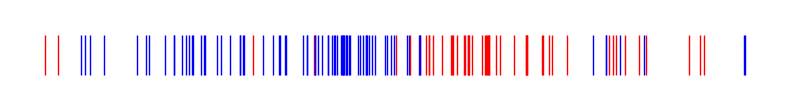

In [165]:

x1d = X_tsne1.ravel()
labels = df_train.loc[X_train_unc.index, LABEL_COL].to_numpy()

# map class → colour (same scheme as before)
colormap = {1: "red", 2: "blue"}
cols     = [colormap[l] for l in labels]

# ───────────────────────── 1-D coloured line ─────────────────────────────
fig, ax = plt.subplots(figsize=(8, 1.2))

# one tick per point: marker "|" is a short vertical line
ax.scatter(
    x1d, np.zeros_like(x1d),      # y = 0 ⇒ *no* second dimension
    c=cols, marker="|", s=800,    # s controls length & thickness
    linewidths=1
)

ax.set_axis_off()                # kill all axes, ticks, spines
plt.tight_layout()
plt.show()


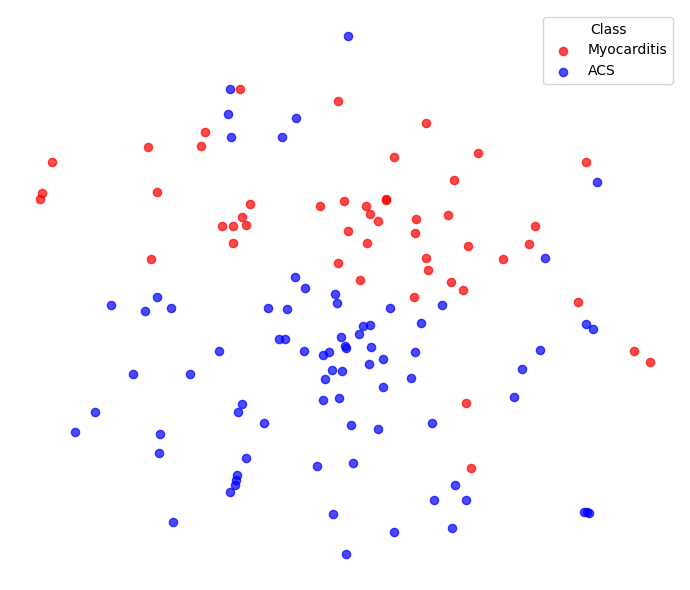

In [166]:
tsne = TSNE(n_components=2, perplexity=50, learning_rate='auto',
            init='pca', random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

labels = df_train.loc[X_train_unc.index, LABEL_COL].to_numpy()

plt.figure(figsize=(7,6))

# Plot each class separately with label for legend
for cls, color in zip([1, 2], ['red', 'blue']):
    idx = labels == cls
    if cls == 1:
        plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1],
                c=color, label=f'Myocarditis', s=35, alpha=0.7)
    if cls == 2:
        plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1],
                c=color, label=f'ACS', s=35, alpha=0.7)


plt.xlabel('t-SNE-1')
plt.ylabel('t-SNE-2')
#plt.title(f't-SNE projection of the uncertainty matrix X')

plt.gca().set_axis_off()

plt.legend(title="Class", loc='best')
plt.tight_layout()

plt.savefig("tSNE.pdf", dpi=300)
plt.show()

In [167]:
# NOTE: Do NOT save embedding artifacts here.
# app_artifacts/ is managed exclusively by generate_embedding.py,
# which uses the fitted model's UncertaintyTransformer for consistency.
# Run generate_embedding.py after retraining to update app_artifacts/.
print("Embedding computed for visualization. To update app_artifacts/, run generate_embedding.py.")

Embedding computed for visualization. To update app_artifacts/, run generate_embedding.py.


In [168]:
X_tsne.shape

(128, 2)

In [169]:

plt.rcParams["figure.figsize"] = (7, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 12


In [170]:
# Padding around extreme points so contours don't touch the frame
pad = 2.0

xmin, xmax = X_tsne[:, 0].min() - pad, X_tsne[:, 0].max() + pad
ymin, ymax = X_tsne[:, 1].min() - pad, X_tsne[:, 1].max() + pad

# 250×250 grid (adjust for speed ↔ smoothness)
resolution = 1000
xs = np.linspace(xmin, xmax, resolution)
ys = np.linspace(ymin, ymax, resolution)
xx, yy = np.meshgrid(xs, ys)
grid = np.vstack([xx.ravel(), yy.ravel()])


In [171]:
class1 = X_tsne[labels == 1]
class2 = X_tsne[labels == 2]

kde1 = gaussian_kde(class1.T, bw_method="scott")
kde2 = gaussian_kde(class2.T, bw_method="scott")

z1 = kde1(grid).reshape(xx.shape)
z2 = kde2(grid).reshape(xx.shape)


In [172]:
z1[2,5]

np.float64(6.826238259987261e-42)

In [173]:
q = 0.6                                                     # 60 % iso-density
level1 = np.quantile(z1, q)
level2 = np.quantile(z2, q)

overlap = (z1 >= level1) & (z2 >= level2)

In [174]:
# --- 6.  Build alpha masks & colour-shift for the overlap -----------------
def normalise(z, clip=0.98):
    """Scale density field to 0–1, clipping the top `clip` quantile."""
    zmax = np.quantile(z, clip)
    return np.clip(z / zmax, 0, 1)

# -------------------------------------------------------------------------
# 1) Alpha masks for the *pure* class regions (same idea as before)
# -------------------------------------------------------------------------
alpha1 = normalise(z1)**0.5
alpha2 = normalise(z2)**0.5
alpha1[z1 < level1] = 0.0
alpha2[z2 < level2] = 0.0

# -------------------------------------------------------------------------
# 2) Identify the overlap and give it its own alpha map
# -------------------------------------------------------------------------
overlap_mask      = (alpha1 > 0) & (alpha2 > 0)
alpha_overlap     = np.maximum(alpha1, alpha2)
alpha_overlap[~overlap_mask] = 0.0

# Remove the red/blue alphas *inside* the overlap so they don't sit on top
alpha1[overlap_mask] = 0.0
alpha2[overlap_mask] = 0.0

# -------------------------------------------------------------------------
# 3) Per-pixel colour for the overlap
#    • Start from mid-grey  (0.5, 0.5, 0.5)
#    • Shift toward red or blue according to local dominance
# -------------------------------------------------------------------------
eps   = 1e-12                    # avoid division by zero
total = z1 + z2 + eps
t     = (z1 - z2) / total        # -1 ⟶ pure blue side, +1 ⟶ pure red side

shift_strength = 0.3    # 0 → always grey, base_gray → full red/blue at edge

# Base: all grey
R = np.full_like(t, 0.5)
G = np.full_like(t, 0.5)
B = np.full_like(t, 0.5)

# Shift toward red where t > 0
pos          = t > 0
R[pos] += shift_strength * t[pos]
G[pos] -= shift_strength * t[pos]
B[pos] -= shift_strength * t[pos]

# Shift toward blue where t < 0
neg          = t < 0
B[neg] += shift_strength * (-t[neg])
R[neg] -= shift_strength * (-t[neg])
G[neg] -= shift_strength * (-t[neg])

shape = (*alpha1.shape, 4)        # (Ny, Nx, 4)

red_img  = np.zeros(shape)
red_img[..., 0] = 1.0             # R channel
red_img[..., 3] = alpha1          # alpha   (class-1 density)

blue_img = np.zeros(shape)
blue_img[..., 2] = 1.0            # B channel
blue_img[..., 3] = alpha2         # alpha   (class-2 density)

# Build the RGBA image for the overlap
shape      = (*alpha_overlap.shape, 4)
over_img   = np.zeros(shape)
over_img[..., 0] = R
over_img[..., 1] = G
over_img[..., 2] = B
over_img[..., 3] = alpha_overlap        # density-weighted fade-out


Saved: app_artifacts/diagnostic_landscape.png


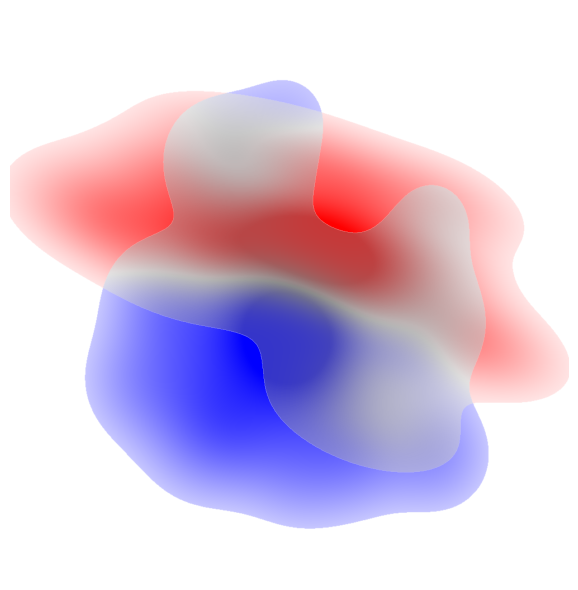

In [175]:
# --- Plot, final clean look ----------------------------------------------
fig, ax = plt.subplots()

# Filled RGBA layers (unchanged)
for img in [over_img, red_img, blue_img]:
    ax.imshow(img, extent=(xmin, xmax, ymin, ymax), origin="lower", interpolation="bilinear")

ax.set_axis_off()

plt.tight_layout()
plt.savefig("viz.pdf", dpi=300)

# Save for app welcome screen (no legend — plotly overlay provides the legend)
import os
os.makedirs("app_artifacts", exist_ok=True)
fig.savefig("app_artifacts/diagnostic_landscape.png", dpi=150, bbox_inches="tight", facecolor="white")
print("Saved: app_artifacts/diagnostic_landscape.png")

plt.show()

In [176]:
# class distribution
print(df_clean[LABEL_COL].value_counts())
print(df_clean[LABEL_COL].value_counts(normalize=True))

GRUP
2    97
1    63
Name: count, dtype: int64
GRUP
2    0.60625
1    0.39375
Name: proportion, dtype: float64


In [177]:
# ============================================================================
# Baseline Models
# ============================================================================

baseline_models = {
    "k-NN (k = 15)": KNeighborsClassifier(n_neighbors=15),
    "Random Forest": RandomForestClassifier(
      n_estimators=300,
      max_depth=4,
      min_samples_leaf=5,
      min_samples_split=10,
      max_features=0.5,
      class_weight="balanced",
      random_state=42
    ),
    "SVC (RBF)":     SVC(kernel="rbf", probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=3000)
}

def make_baseline_pipeline(model):
    """
    Create a pipeline with UncertaintyTransformer, StandardScaler, and model.
    
    Parameters
    ----------
    model : classifier
        The classifier to use in the pipeline.
        How to handle NaN values:
        - 'error': Raise error if NaNs detected
        - 'warn': Replace with 0 and issue warning
        - 'zero': Silently replace with 0
    """
    return Pipeline([
        ("uncertainty", UncertaintyTransformer(
            feature_names=features,
            class_labels=None,
            n_bins=N_BINS,
            eps=EPS,
        )),
        ("scaler", StandardScaler()),
        ("clf", model),
    ])

print("Baseline models defined:")
for name in baseline_models.keys():
    print(f"  - {name}")

Baseline models defined:
  - k-NN (k = 15)
  - Random Forest
  - SVC (RBF)
  - Logistic Regression


In [178]:
# IMPORTS

from sklearn.model_selection import cross_validate

In [179]:
# ============================================================================
# Baseline Model Evaluation
# ============================================================================
# 5-fold CV for every model
# only on TRAIN

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline_results = []

for model_name, model in baseline_models.items():
    print(f"\nEvaluating {model_name}...")
    
    pipeline = make_baseline_pipeline(model)
    
    cv_results = cross_validate(
        pipeline,
        X_train_raw,
        y_train,
        cv=cv,
        scoring={
            'accuracy': 'accuracy',
            'precision_macro': 'precision_macro',
            'recall_macro': 'recall_macro',
            'f1_macro': 'f1_macro'
        },
        return_train_score=False, 
        n_jobs=-1
    )
    
    # store results
    baseline_results.append({
        'Model': model_name,
        'Accuracy': f"{cv_results['test_accuracy'].mean():.3f} ± {cv_results['test_accuracy'].std():.3f}",
        'Precision (macro)': f"{cv_results['test_precision_macro'].mean():.3f} ± {cv_results['test_precision_macro'].std():.3f}",
        'Recall (macro)': f"{cv_results['test_recall_macro'].mean():.3f} ± {cv_results['test_recall_macro'].std():.3f}",
        'F1 (macro)': f"{cv_results['test_f1_macro'].mean():.3f} ± {cv_results['test_f1_macro'].std():.3f}",
        '_recall_mean': cv_results['test_recall_macro'].mean(),
    })

baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df = baseline_results_df.sort_values('_recall_mean', ascending=False)
baseline_results_df = baseline_results_df.drop(columns=['_recall_mean'])

print("\n" + "="*80)
print("BASELINE MODEL RESULTS (5-Fold Stratified CV on TRAIN)")
print("="*80)
print(baseline_results_df.to_string(index=False))
print("="*80)


Evaluating k-NN (k = 15)...

Evaluating Random Forest...

Evaluating SVC (RBF)...

Evaluating Logistic Regression...

BASELINE MODEL RESULTS (5-Fold Stratified CV on TRAIN)
              Model      Accuracy Precision (macro) Recall (macro)    F1 (macro)
Logistic Regression 0.946 ± 0.046     0.951 ± 0.040  0.941 ± 0.056 0.942 ± 0.051
      Random Forest 0.946 ± 0.018     0.949 ± 0.025  0.936 ± 0.015 0.942 ± 0.019
          SVC (RBF) 0.876 ± 0.070     0.900 ± 0.060  0.846 ± 0.085 0.858 ± 0.083
      k-NN (k = 15) 0.852 ± 0.066     0.906 ± 0.037  0.806 ± 0.087 0.820 ± 0.087


# ============================================================================
# LEARNING CURVE ANALYSIS
# ============================================================================


Computing learning curve for k-NN (k = 15)...


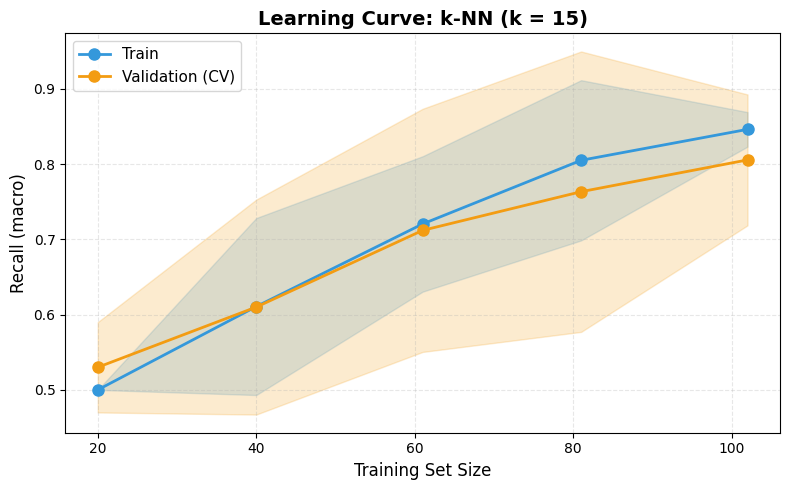

  Final train score: 0.846 ± 0.023
  Final validation score: 0.806 ± 0.087
  ✓ Small gap (0.041) suggests good generalization

Computing learning curve for Random Forest...


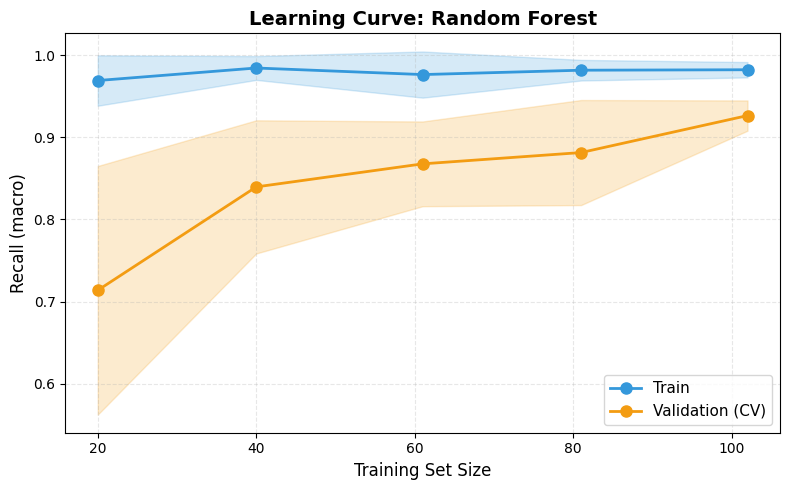

  Final train score: 0.982 ± 0.009
  Final validation score: 0.926 ± 0.018
  → Moderate gap (0.056)

Computing learning curve for SVC (RBF)...


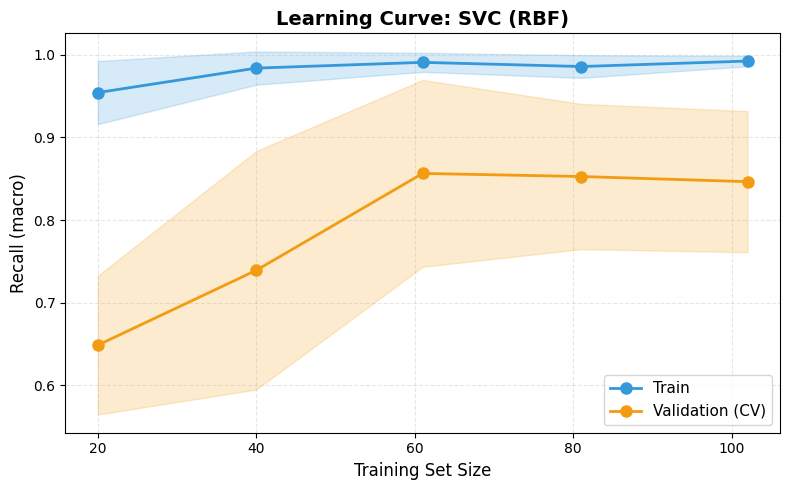

  Final train score: 0.992 ± 0.006
  Final validation score: 0.846 ± 0.085
  → Moderate gap (0.146)

Computing learning curve for Logistic Regression...


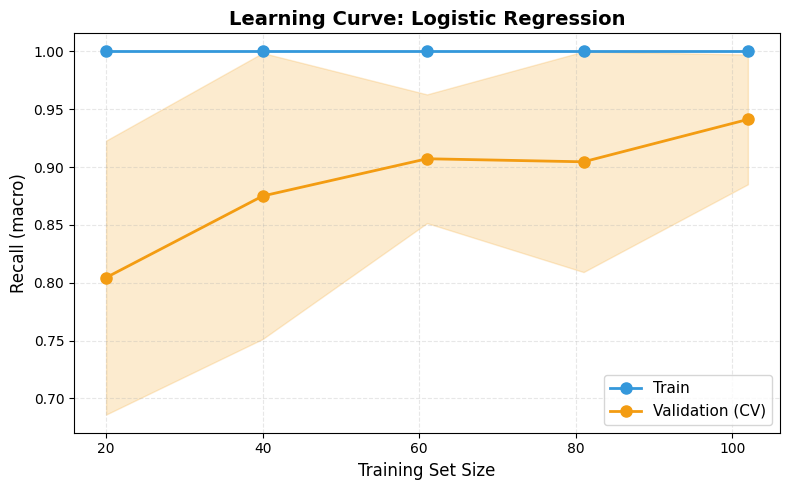

  Final train score: 1.000 ± 0.000
  Final validation score: 0.941 ± 0.056
  → Moderate gap (0.059)

LEARNING CURVE ANALYSIS COMPLETE

Interpretation:
  - If validation score plateaus early → model may need more data
  - If large gap between train/val → potential overfitting
  - If both scores are low → potential underfitting


In [180]:
# ============================================================================
# LEARNING CURVE COMPUTATION AND VISUALIZATION
# ============================================================================

train_sizes = np.linspace(0.2, 1.0, 5) 

# define CV for learning curves
cv_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# compute learning curves for each baseline model
for model_name, model in baseline_models.items():
    print(f"\nComputing learning curve for {model_name}...")
    
    pipeline = make_baseline_pipeline(model)
    
    train_sizes_abs, train_scores, val_scores = learning_curve(
        pipeline,
        X_train_raw,
        y_train,
        train_sizes=train_sizes,
        cv=cv_lc,
        scoring='recall_macro',  # primary metric
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )
    
    # calculate stats
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    val_scores_mean = np.mean(val_scores, axis=1)
    val_scores_std = np.std(val_scores, axis=1)
    
    plt.figure(figsize=(8, 5))
    
    plt.plot(train_sizes_abs, train_scores_mean, 'o-', color='#3498DB', 
             label='Train', linewidth=2, markersize=8)
    plt.fill_between(train_sizes_abs, 
                     train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std,
                     alpha=0.2, color='#3498DB')
    
    plt.plot(train_sizes_abs, val_scores_mean, 'o-', color='#F39C12',
             label='Validation (CV)', linewidth=2, markersize=8)
    plt.fill_between(train_sizes_abs,
                     val_scores_mean - val_scores_std,
                     val_scores_mean + val_scores_std,
                     alpha=0.2, color='#F39C12')
    
    plt.xlabel('Training Set Size', fontsize=12)
    plt.ylabel('Recall (macro)', fontsize=12)
    plt.title(f'Learning Curve: {model_name}', fontsize=14, fontweight='bold')
    plt.legend(loc='best', fontsize=11)
    plt.grid(alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
    
    print(f"  Final train score: {train_scores_mean[-1]:.3f} ± {train_scores_std[-1]:.3f}")
    print(f"  Final validation score: {val_scores_mean[-1]:.3f} ± {val_scores_std[-1]:.3f}")
    
    # check for underfitting/overfitting
    gap = train_scores_mean[-1] - val_scores_mean[-1]
    if gap > 0.15:
        print(f"  ⚠️  Large gap ({gap:.3f}) suggests potential overfitting")
    elif gap < 0.05:
        print(f"  ✓ Small gap ({gap:.3f}) suggests good generalization")
    else:
        print(f"  → Moderate gap ({gap:.3f})")

print("\n" + "="*80)
print("LEARNING CURVE ANALYSIS COMPLETE")
print("="*80)
print("\nInterpretation:")
print("  - If validation score plateaus early → model may need more data")
print("  - If large gap between train/val → potential overfitting")
print("  - If both scores are low → potential underfitting")
print("="*80)

In [181]:
# ============================================================================
# LOADING FINETUNED MODEL
# ============================================================================
import os

model_path = 'best_model_finetuned.pkl'
metadata_path = 'model_metadata.pkl'

if not os.path.exists(model_path):
    raise FileNotFoundError(
        f"Model file '{model_path}' not found. "
        "Please run NEW-finetuning.ipynb first to train and save the model."
    )

if not os.path.exists(metadata_path):
    raise FileNotFoundError(
        f"Metadata file '{metadata_path}' not found. "
        "Please run NEW-finetuning.ipynb first to save model metadata."
    )

# Load the finetuned model (full pipeline: UncertaintyTransformer + StandardScaler + Classifier)
with open(model_path, 'rb') as f:
    finetuned_model = pickle.load(f)

# Load metadata
with open(metadata_path, 'rb') as f:
    model_metadata = pickle.load(f)

print("=" * 80)
print("LOADED FINETUNED MODEL FROM NEW-finetuning.ipynb")
print("=" * 80)
print(f"\nModel loaded from: {model_path}")
print(f"Metadata loaded from: {metadata_path}")
print(f"\nModel pipeline steps:")
for name, step in finetuned_model.named_steps.items():
    print(f"  - {name}: {type(step).__name__}")
print(f"\nMetadata:")
print(f"  - Features: {len(model_metadata['features'])} features")
print(f"  - Class labels: {model_metadata['class_labels']}")
print(f"  - N_BINS: {model_metadata['n_bins']}")
print(f"  - EPS: {model_metadata['eps']}")
print("=" * 80)
print("\nThe finetuned model is now available as 'finetuned_model' for use in this notebook.")

LOADED FINETUNED MODEL FROM NEW-finetuning.ipynb

Model loaded from: best_model_finetuned.pkl
Metadata loaded from: model_metadata.pkl

Model pipeline steps:
  - uncertainty: UncertaintyTransformer
  - scaler: StandardScaler
  - clf: VotingClassifier

Metadata:
  - Features: 44 features
  - Class labels: (np.int64(1), np.int64(2))
  - N_BINS: 20
  - EPS: 1e-12

The finetuned model is now available as 'finetuned_model' for use in this notebook.


In [182]:
# ============================================================================
# FINETUNED MODEL - CV PERFORMANCE ON TRAIN SET
# ============================================================================

from sklearn.model_selection import cross_validate

print("=" * 80)
print("FINETUNED MODEL - CV PERFORMANCE ON TRAIN SET")
print("=" * 80)

from sklearn.base import clone

print(f"\nModel: {model_metadata['model_name']}")

# clone handles VotingClassifier and single-clf pipelines alike
def make_finetuned_pipeline():
    """Create a fresh unfitted pipeline clone for CV / learning curve."""
    return clone(finetuned_model)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    make_finetuned_pipeline(),
    X_train_raw,
    y_train,
    cv=cv,
    scoring={
        'accuracy': 'accuracy',
        'precision_macro': 'precision_macro',
        'recall_macro': 'recall_macro',
        'f1_macro': 'f1_macro'
    },
    return_train_score=False,
    n_jobs=-1
)

print(f"\n5-Fold Stratified CV Results (mean ± std):")
print("-" * 40)
print(f"  Accuracy:  {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"  Precision: {cv_results['test_precision_macro'].mean():.4f} ± {cv_results['test_precision_macro'].std():.4f}")
print(f"  Recall:    {cv_results['test_recall_macro'].mean():.4f} ± {cv_results['test_recall_macro'].std():.4f}")
print(f"  F1-score:  {cv_results['test_f1_macro'].mean():.4f} ± {cv_results['test_f1_macro'].std():.4f}")
print("=" * 80)

FINETUNED MODEL - CV PERFORMANCE ON TRAIN SET

Model: VotingClassifier(LogisticRegression+SVC+RandomForestClassifier)

5-Fold Stratified CV Results (mean ± std):
----------------------------------------
  Accuracy:  0.9538 ± 0.0377
  Precision: 0.9560 ± 0.0373
  Recall:    0.9512 ± 0.0415
  F1-score:  0.9510 ± 0.0401


LEARNING CURVE FOR FINETUNED MODEL
Model: VotingClassifier(LogisticRegression+SVC+RandomForestClassifier)

Computing learning curve...


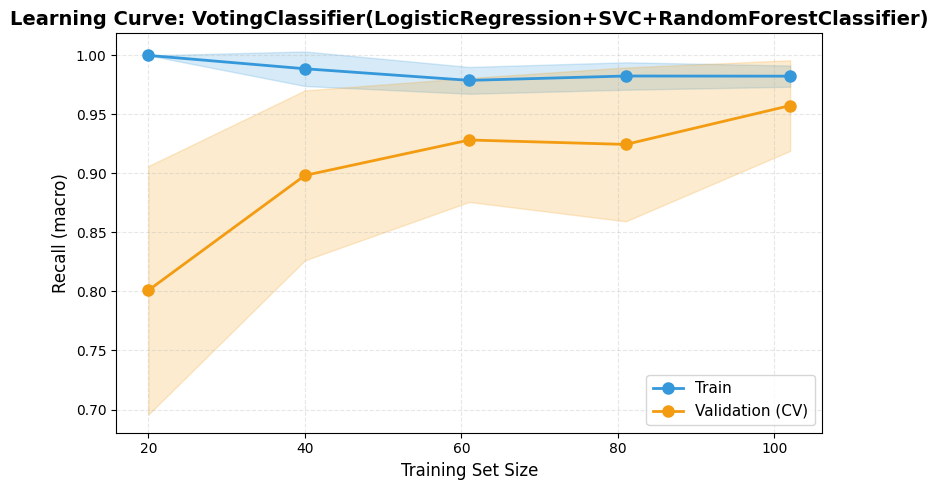


Final train score: 0.982 ± 0.009
Final validation score: 0.957 ± 0.038
✓ Small gap (0.025) suggests good generalization


In [183]:
# ============================================================================
# LEARNING CURVE FOR FINETUNED MODEL
# ============================================================================

print("=" * 80)
print("LEARNING CURVE FOR FINETUNED MODEL")
print("=" * 80)

# get the classifier from the finetuned pipeline to create fresh instances for LC
from sklearn.base import clone

print(f"Model: {model_metadata['model_name']}")

# clone handles VotingClassifier and single-clf pipelines alike
# compute learning curve
train_sizes_lc = np.linspace(0.2, 1.0, 5)
cv_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\nComputing learning curve...")

train_sizes_abs, train_scores, val_scores = learning_curve(
    make_finetuned_pipeline(),
    X_train_raw,
    y_train,
    train_sizes=train_sizes_lc,
    cv=cv_lc,
    scoring='recall_macro',
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

# calculate stats
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)
val_scores_std = np.std(val_scores, axis=1)

plt.figure(figsize=(8, 5))

plt.plot(train_sizes_abs, train_scores_mean, 'o-', color='#3498DB', 
         label='Train', linewidth=2, markersize=8)
plt.fill_between(train_sizes_abs, 
                 train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std,
                 alpha=0.2, color='#3498DB')

plt.plot(train_sizes_abs, val_scores_mean, 'o-', color='#F39C12',
         label='Validation (CV)', linewidth=2, markersize=8)
plt.fill_between(train_sizes_abs,
                 val_scores_mean - val_scores_std,
                 val_scores_mean + val_scores_std,
                 alpha=0.2, color='#F39C12')

plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('Recall (macro)', fontsize=12)
plt.title(f"Learning Curve: {model_metadata['model_name']}", fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print(f"\nFinal train score: {train_scores_mean[-1]:.3f} ± {train_scores_std[-1]:.3f}")
print(f"Final validation score: {val_scores_mean[-1]:.3f} ± {val_scores_std[-1]:.3f}")

# check for underfitting/overfitting
gap = train_scores_mean[-1] - val_scores_mean[-1]
if gap > 0.15:
    print(f"  Large gap ({gap:.3f}) suggests potential overfitting")
elif gap < 0.05:
    print(f"✓ Small gap ({gap:.3f}) suggests good generalization")
else:
    print(f"→ Moderate gap ({gap:.3f})")

print("=" * 80)